In [21]:
!python --version

Python 3.10.14


# ***Packages***

In [22]:
# %pip install matplotlib
# %pip install scanpy
# %pip install tqdm
# %pip install torch

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

In [24]:
import locale
import inspect
import os
import sys
locale.getpreferredencoding = lambda: "UTF-8"

sys.path.append('MODIFIED_PYTHON_MODULES/modified_ot')
import ot

module_path = inspect.getfile(ot)
# Get the directory containing the module
module_directory = os.path.dirname(module_path)

print(f"Module directory: {module_directory}")

sys.path.append('MODIFIED_PYTHON_MODULES/modified_paste')
import paste as pst

module_path = inspect.getfile(pst)
module_directory = os.path.dirname(module_path)

print(f"Module directory: {module_directory}")


Module directory: c:\Users\Anup\Desktop\Essentials\dev-drive\promt\MODIFIED_PYTHON_MODULES/modified_ot\ot
Module directory: c:\Users\Anup\Desktop\Essentials\dev-drive\promt\MODIFIED_PYTHON_MODULES/modified_paste\paste


Check for GPU support

In [25]:
!nvidia-smi

Mon Oct 28 23:14:35 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.03                 Driver Version: 566.03         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   71C    P0             24W /   60W |     584MiB /   3072MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# ***Data***

In [26]:
def load_data(data_dir, data1, data2):    

    sliceA = sc.read_h5ad(data_dir + data1 + ".h5ad")
    sliceB = sc.read_h5ad(data_dir + data2 + ".h5ad")

    xI = np.array(sliceA.obsm['spatial'] [:, 0])
    yI = np.array(sliceA.obsm['spatial'] [:, 1])

    xJ = np.array(sliceB.obsm['spatial'] [:, 0])
    yJ = np.array(sliceB.obsm['spatial'] [:, 1])

    plt.scatter(xI,yI,s=1,alpha=1, label='source')
    plt.axis("off")
    plt.legend()
    plt.show()

    plt.scatter(xJ,yJ,s=1,alpha=1, c='#ff7f0e',  label='target')
    plt.axis("off")
    plt.legend()
    plt.show()

    return sliceA, sliceB


In [27]:
def visualize_alignment(sliceA, sliceB, pi12):
    slices, pis = [sliceA, sliceB], [pi12]
    new_slices = pst.stack_slices_pairwise(slices, pis)

    slice_colors = ['#e41a1c','#377eb8']

    xI_new = new_slices[0].obsm['spatial'][:, 0]
    yI_new = new_slices[0].obsm['spatial'][:, 1]

    xJ_new = new_slices[1].obsm['spatial'][:, 0]
    yJ_new = new_slices[1].obsm['spatial'][:, 1]

    print("====================\nAligned slices")

    plt.scatter(xI_new,yI_new,s=1,alpha=0.5, label='source', c=slice_colors[0])
    plt.scatter(xJ_new,yJ_new,s=1,alpha=0.5, label = 'target', c=slice_colors[1])
    plt.axis("off")
    plt.legend()
    plt.show()

    return new_slices

    

# ***Apply Method***

In [28]:
def cell_type_matching_metric_stalign(threshold, slice1, slice2):
    from sklearn.metrics.pairwise import euclidean_distances

    matching_cell_types = 0

    # Extract coordinates from both slices
    source_coords = slice1.obsm['spatial']
    target_coords = slice2.obsm['spatial']

    # Calculate pairwise Euclidean distances using cdist_sparse
    distances = euclidean_distances(source_coords, target_coords)

    processed_target_cells = set()

    # Iterate through each cell in the source slice
    for source_cell_index in range(distances.shape[0]):
        # find the indices of target cells within the threshold
        target_indices = np.where(distances[source_cell_index] <= threshold)[0]
        if len(target_indices) == 0:
            # print("nothing found")
            continue

        # if any one of the target cells are of the same cell_type of the current source cell incrase count
        for target_cell_index in target_indices:
            if target_cell_index not in processed_target_cells and slice1.obs['cell_type_annot'][source_cell_index] == slice2.obs['cell_type_annot'][target_cell_index]:
                matching_cell_types += 1
                processed_target_cells.add(target_cell_index)
                break
    
    percentage = matching_cell_types / slice1.n_obs * 100

    print(f"Number of matching cell types within {threshold}um distance: {matching_cell_types}")
    print(f"Percentage of matching cell types within {threshold}um distance: {percentage:.4f}%")

    return matching_cell_types, percentage


In [29]:
def run_stalign(sliceA, sliceB, data1, data2, dataPath):
    from STalign import STalign
    import torch
    from sklearn.metrics.pairwise import euclidean_distances, cosine_distances

    def get_neighborhood_distribution(curr_slice, radius):
        """
        This method is added by Anup Bhowmik
        Args:
            curr_slice: Slice to get niche distribution for.
            pairwise_distances: Pairwise distances between cells of a slice.
            radius: Radius of the niche.

        Returns:
            niche_distribution: Niche distribution for the slice.
        """

        unique_cell_types = np.array(list(curr_slice.obs['cell_type_annot'].unique()))
        cell_type_to_index = dict(zip(unique_cell_types, list(range(len(unique_cell_types)))))
        cells_within_radius = np.zeros((curr_slice.shape[0], len(unique_cell_types)), dtype=float)

        source_coords = curr_slice.obsm['spatial']
        distances = euclidean_distances(source_coords, source_coords)

        for i in range(curr_slice.shape[0]):
            # find the indices of the cells within the radius

            target_indices = np.where(distances[i] <= radius)[0]

            for ind in target_indices:
                cell_type_str_j = str(curr_slice.obs['cell_type_annot'][ind])
                cells_within_radius[i][cell_type_to_index[cell_type_str_j]] += 1

        return np.array(cells_within_radius)
    
    def cellular_neighborhood_gene_expr_metric(radius, slice1, slice2):

        pi_mat = np.zeros((slice1.shape[0], slice2.shape[0]))

        # Extract coordinates from both slices
        source_coords = slice1.obsm['spatial']
        target_coords = slice2.obsm['spatial']

        # Calculate pairwise Euclidean distances using cdist_sparse
        distances = euclidean_distances(source_coords, target_coords)

        # Process the priority queue to ensure only one match per source cell
        processed_source_cells = set()


        # Iterate through each cell in the source slice
        for source_cell_index in range(distances.shape[0]):

            # Find the index of the closest target cell within the threshold
            closest_target_index = distances[source_cell_index].argmin()  # Find the index of the minimum distance

            # allowing one to many mapping
            if source_cell_index in processed_source_cells:
                continue

            # Check if the closest distance is within the threshold
            # if closest_distance <= threshold:
            processed_source_cells.add(source_cell_index)
            # processed_target_cells.add(closest_target_index)
            pi_mat[source_cell_index, closest_target_index] = 1/slice1.n_obs


        neighborhood_dist_slice1 = get_neighborhood_distribution(slice1, radius) + 0.01
        neighborhood_dist_slice2 = get_neighborhood_distribution(slice2, radius) + 0.01

        js_dist_neighborhood = pst.helper.jensenshannon_divergence_backend(neighborhood_dist_slice1, neighborhood_dist_slice2)
        js_dist_neighborhood = np.asarray(js_dist_neighborhood)

        # calculate cosine dist gene expr metric
        s_A = slice1.X + 0.01
        s_B = slice2.X + 0.01

        cosine_dist_gene_expr = cosine_distances(s_A, s_B)
        final_obj_gene_cos = np.sum(cosine_dist_gene_expr * pi_mat)

        final_obj_neighbor = np.sum(js_dist_neighborhood*pi_mat)

        return pi_mat, final_obj_neighbor, final_obj_gene_cos, js_dist_neighborhood


    # Run STalign pipeline
    if os.path.exists(f'{dataPath}/tpointsI_{data1}.npy'):
        tpointsI = np.load(f'{dataPath}/tpointsI_{data1}.npy')

    else:
        xI = np.array(sliceA.obsm['spatial'] [:, 0])
        yI = np.array(sliceA.obsm['spatial'] [:, 1])

        xJ = np.array(sliceB.obsm['spatial'] [:, 0])
        yJ = np.array(sliceB.obsm['spatial'] [:, 1])

        # rasterize at 30um resolution (assuming positions are in um units) and plot
        XI,YI,I,fig = STalign.rasterize(xI,yI,dx=30,blur=1.5)
        XJ,YJ,J,fig = STalign.rasterize(xJ,yJ,dx=30, blur=1.5)

        # get extent of images
        extentI = STalign.extent_from_x((YI,XI))
        extentJ = STalign.extent_from_x((YJ,XJ))

        # run LDDMM
        # specify device (default device for STalign.LDDMM is cpu)
        if torch.cuda.is_available():
            device = 'cuda:0'
        else:
            device = 'cpu'

        # keep all other parameters default
        params = {
                    'niter': 5000,
                    'device':device,
                    'epV': 50
                }

        out = STalign.LDDMM([YI,XI],I,[YJ,XJ],J,**params)

        # get necessary output variables
        A = out['A']
        v = out['v']
        xv = out['xv']

        # set device for building tensors
        if torch.cuda.is_available():
            torch.set_default_device('cuda:0')
        else:
            torch.set_default_device('cpu')

        # apply transform
        phii = STalign.build_transform(xv,v,A,XJ=[YJ,XJ],direction='b')
        phiI = STalign.transform_image_source_to_target(xv,v,A,[YI,XI],I,[YJ,XJ])

        #switch tensor from cuda to cpu for plotting with numpy
        if phii.is_cuda:
            phii = phii.cpu()
        if phiI.is_cuda:
            phiI = phiI.cpu()


        # transform is invertible
        phi = STalign.build_transform(xv,v,A,XJ=[YI,XI],direction='f')
        phiiJ = STalign.transform_image_target_to_source(xv,v,A,[YJ,XJ],J,[YI,XI])

        #switch tensor from cuda to cpu for plotting with numpy
        if phi.is_cuda:
            phi = phi.cpu()
        if phiiJ.is_cuda:
            phiiJ = phiiJ.cpu()

        # apply transform to original points
        tpointsI= STalign.transform_points_source_to_target(xv,v,A, np.stack([YI,XI], 1))

        #switch tensor from cuda to cpu for plotting with numpy
        if tpointsI.is_cuda:
            tpointsI = tpointsI.cpu()

        np.save(f'{dataPath}/tpointsI_{data1}.npy', tpointsI)

    # switch from row column coordinates (y,x) to (x,y)
    xI_LDDMM = tpointsI[:,1]
    yI_LDDMM = tpointsI[:,0]

    # re-center the transformed points
    centroid_I = np.mean(np.vstack((xI_LDDMM, yI_LDDMM)), axis=1)
    centroid_J = np.mean(np.vstack((xJ, yJ)), axis=1)
    translation_vector = centroid_J - centroid_I
    xI_LDDMM = xI_LDDMM + translation_vector[0]
    yI_LDDMM = yI_LDDMM + translation_vector[1]

    # visualize the alignment
    plt.clf()
    plt.scatter(xI_LDDMM,yI_LDDMM,s=1,alpha=0.4, label = 'source STaligned')
    plt.scatter(xJ,yJ,s=1,alpha=0.2, label='target')
    plt.legend(markerscale = 10, loc = 'lower left')
    plt.axis("off")
    plt.show()
    plt.clf()

    sliceA_LDDMM = sliceA.copy()
    # update the spatial coordinates
    sliceA_LDDMM.obsm['spatial'][:, 0] = xI_LDDMM
    sliceA_LDDMM.obsm['spatial'][:, 1] = yI_LDDMM

    new_slices = [sliceA_LDDMM, sliceB]

    radius = 100
    pi_mat, final_obj_neighbor, final_obj_gene_cos, js_dist_neighborhood = cellular_neighborhood_gene_expr_metric(radius, sliceA_LDDMM, sliceB)

    a = np.ones((sliceA.shape[0],))/sliceA.shape[0]
    b = np.ones((sliceB.shape[0],))/sliceB.shape[0]
    G = np.ones((a.shape[0], b.shape[0])) / (a.shape[0] * b.shape[0])

    initial_obj_neighbor = np.sum(js_dist_neighborhood*G)
    initial_obj_gene_cos = np.sum(cosine_distances(sliceA.X, sliceB.X)*G)

    return pi_mat, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos, new_slices


In [30]:
def run_method(sliceA, sliceB, data1, data2, method_name):

    if method_name.lower() == 'promt':

        pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos = pst.pairwise_align_MERFISH(sliceA = sliceA, sliceB = sliceB, backend = ot.backend.TorchBackend(),
                                            use_gpu = True, return_obj = True,
                                            sliceA_name=data1, sliceB_name=data2, alpha=0.1, beta= 0.8, gamma=0.8, radius=100,
                                            numItermax = 20000, overwrite = True, neighborhood_dissimilarity = 'jsd',
                                            filePath = f'{os.getcwd()}/local_data/{method_name}')
        
        new_slices = visualize_alignment(sliceA, sliceB, pi12)
        return pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos, new_slices
    
    elif method_name.lower() == 'paste':

        pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos = pst.pairwise_align(sliceA = sliceA, sliceB = sliceB, backend = ot.backend.TorchBackend(),
                                    use_gpu = True, return_obj = True,
                                    sliceA_name=data1, sliceB_name=data2, alpha=0.1, beta= 0.8, gamma=0.8, radius=100,
                                    numItermax = 20000, overwrite = True,
                                    filePath = f'{os.getcwd()}/local_data/{method_name}')

        new_slices = visualize_alignment(sliceA, sliceB, pi12)
        return pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos, new_slices

    elif method_name.lower() == 'stalign':
        pi12, initial_obj_neighbor, initial_obj_gene_cos, final_obj_neighbor, final_obj_gene_cos, new_slices = run_stalign(sliceA, sliceB, data1, data2, f'{os.getcwd()}/local_data/{method_name}')
    
    else:
        print("Method not found")
        return None


In [31]:
def save_pi_matrix(pi12, data1, data2, method_name):
    filePath = f'{os.getcwd()}/local_data/{method_name}'
    np.save(f"{filePath}/pi_matrix_{data1}_{data2}.npy", pi12)

In [32]:
def cell_type_matching_metric(sliceA, sliceB, pi_mat):

    matching_cell_types = 0

    max_indices = np.argmax(pi_mat, axis=1)
    for i, max_index in enumerate(max_indices):

        if sliceA.obs.iloc[i]['cell_type_annot'] == sliceB.obs.iloc[max_index]['cell_type_annot']:
            matching_cell_types += 1

    percentage = matching_cell_types / sliceA.n_obs * 100
    return matching_cell_types, percentage


In [33]:
def get_perf_metrics(new_slices, pi12, neighbor_initial_obj, initial_obj_gene_cos, neighbor_final_obj, obj_gene_cos, method_name):
    neighborhood_improvement = (neighbor_initial_obj - neighbor_final_obj)/neighbor_initial_obj * 100
    gene_expr_improvement = (initial_obj_gene_cos - obj_gene_cos)/initial_obj_gene_cos * 100

    if method_name.lower() == 'stalign':
        threshold = 200 # 200 um
        matching_cell_types, percentage = cell_type_matching_metric_stalign(threshold, new_slices[0], new_slices[1])
    else:
        matching_cell_types, percentage = cell_type_matching_metric(new_slices[0], new_slices[1], pi12)

    print(f"JSD of Cellular Neighborhood\nBefore: {neighbor_initial_obj:.5f}, After: {neighbor_final_obj:.5f}, Improvement: {neighborhood_improvement:.5f}%")
    print(f"Cosine Distance of Gene Expression\nBefore: {initial_obj_gene_cos:.5f}, After: {obj_gene_cos:.5f}, Improvement: {gene_expr_improvement:.5f}%")
    print(f"Cell-type Correspondence: {percentage:.5f}%")

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_results():
    # Data for different time points
    data = {
        '4_wk': {
            'slice': ['0-1', '0-2', '1-2'],
            'PROMT': [77.0593, 77.1117, 91.8983],
            'STALIGN': [36.2489, 37.9107, 61.8539],
            'PASTE': [9.7848, 10.0038, 26.695],
        },
        '24_wk': {
            'slice': ['0-1', '0-2', '1-2'],
            'PROMT': [82.2038, 86.9426, 83.1548],
            'STALIGN': [79.8965, 83.7662, 76.1152],
            'PASTE': [16.089, 10.8536, 9.0673],
        },
        '90_wk': {
            'slice': ['0-1', '0-2', '1-2'],
            'PROMT': [86.772, 82.3181, 75.4977],
            'STALIGN': [41.4681, 32.9808, 59.4774],
            'PASTE': [0.3632, 28.444, 26.3376],
        }
    }

    # Plotting each dataset
    for week, values in data.items():
        df = pd.DataFrame(values)
        ax = df.plot(x='slice', kind='bar', title=f'Results at {week}', figsize=(8, 5))
        ax.set_ylabel('Cell-type correspondence (%)')
        ax.get_legend().remove()
        plt.xticks(rotation=0)  # Optional: Rotate x-axis labels for better readability
        plt.show()



# ***Reproduce Results***

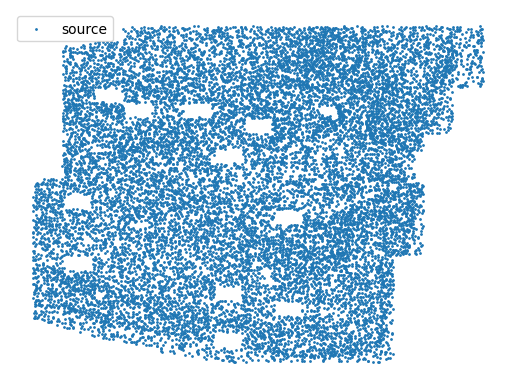

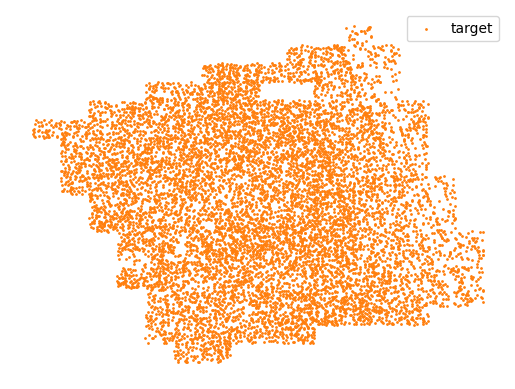

In [35]:
data_dir = "./data/Mouse_brain_MERFISH/"
data1="adata90wk_donor_id_2_slice_0"
data2="adata90wk_donor_id_5_slice_1"

sliceA, sliceB = load_data(data_dir, data1, data2)

In [36]:

# methods = ['promt', 'paste', 'stalign']
methods = ['promt']

for method in methods:
    if not os.path.exists(os.getcwd() + f'/local_data/{method}'):
        os.makedirs(os.getcwd() + f'/local_data/{method}')


: 

In [ ]:

for method in methods:
    print(f"Running {method}")
    pi12, neighbor_initial_obj, initial_obj_gene_cos, neighbor_final_obj, obj_gene_cos, new_slices = run_method(sliceA, sliceB, data1, data2, method)

    if pi12 is None:
        continue

    save_pi_matrix(pi12, data1, data2, method)

    print(f"Performance Metrics for {method}\n=====================================")
    get_perf_metrics(new_slices, pi12, neighbor_initial_obj, initial_obj_gene_cos, neighbor_final_obj, obj_gene_cos, method)

Running promt
gpu is not available, resorting to torch cpu.
CUDA is not available on your system.
Calculating cosine dist of gene expression for slice A and slice B
Saving cosine dist of gene expression for slice A and slice B
Calculating neighborhood distribution of slice A


  0%|          | 0/15694 [00:00<?, ?it/s]c:\Users\Anup\Desktop\Essentials\dev-drive\promt\MODIFIED_PYTHON_MODULES/modified_paste\paste\helper.py:388: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_type_str_j = str(curr_slice.obs['cell_type_annot'][ind])
100%|██████████| 15694/15694 [00:37<00:00, 420.03it/s]


Calculating neighborhood distribution of slice B


  0%|          | 0/9644 [00:00<?, ?it/s]c:\Users\Anup\Desktop\Essentials\dev-drive\promt\MODIFIED_PYTHON_MODULES/modified_paste\paste\helper.py:388: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_type_str_j = str(curr_slice.obs['cell_type_annot'][ind])
100%|██████████| 9644/9644 [00:19<00:00, 496.46it/s]


Calculating JSD of neighborhood distribution for slice A and slice B
Calculating cost matrix


100%|██████████| 15694/15694 [04:15<00:00, 61.48it/s]


Finished calculating cost matrix
alpha: 0.1
beta: 0.8
gamma: 0.8
numItermax: 20000


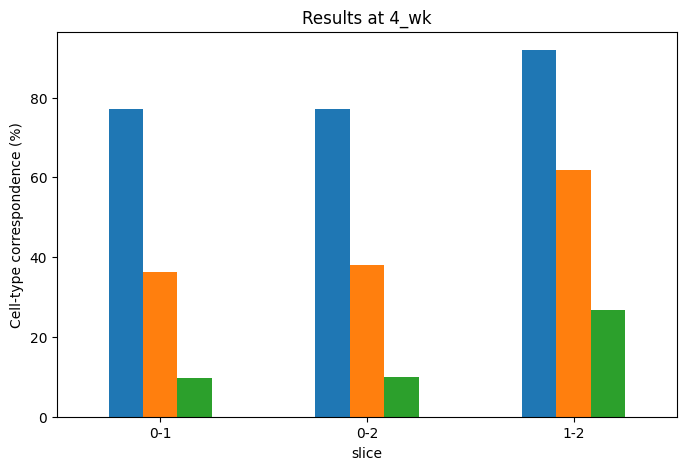

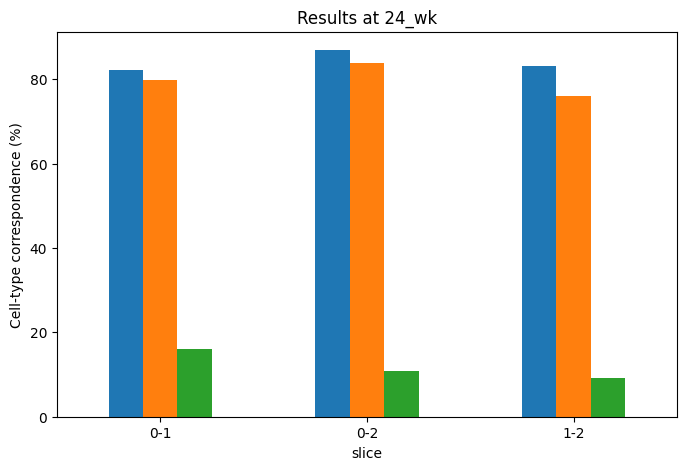

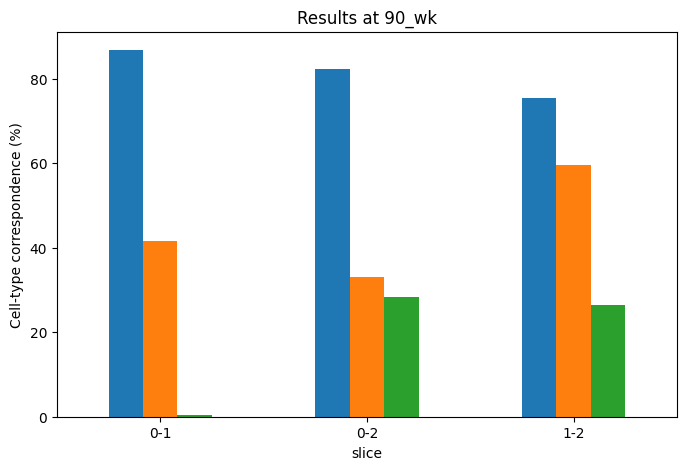

In [18]:
plot_results()